In [8]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# Optional: If you want to handle real PDF files later
# !pip install PyPDF2 

print("Resume Screening Tools are ready!")

Resume Screening Tools are ready!


In [4]:
# 1. The Job we are hiring for
job_description = "Seeking a Software Developer with experience in Python, Machine Learning, and SQL."

# 2. Two different candidates
resume_1 = "I am a Data Scientist skilled in Python and Machine Learning. I love SQL and Data Science."
resume_2 = "I am a Chef with 10 years of experience in Italian cooking and kitchen management."

documents = [job_description, resume_1, resume_2]

# 3. Use TF-IDF to turn them into numbers
tfidf = TfidfVectorizer()
matrix = tfidf.fit_transform(documents)

# 4. Compare Resume 1 and Resume 2 against the Job Description (Index 0)
scores = cosine_similarity(matrix[0:1], matrix[1:])

print(f"Match Score for Candidate 1 (Developer): {scores[0][0]:.2f}")
print(f"Match Score for Candidate 2 (Chef): {scores[0][1]:.2f}")

Match Score for Candidate 1 (Developer): 0.35
Match Score for Candidate 2 (Chef): 0.21


In [5]:
# We will use a URL to a raw CSV of the 'Updated Resume Dataset' 
# This is a famous dataset with 900+ resumes in 25 categories
url = "https://raw.githubusercontent.com/Kira2168/Resume-Screening-Dataset/main/UpdatedResumeDataSet.csv"

try:
    resume_df = pd.read_csv(url)
except:
    # If the URL fails, we can create a slightly larger dummy set to keep moving
    data = {
        'Category': ['Data Science']*5 + ['Java Developer']*5 + ['HR']*5,
        'Resume': [
            "Python Machine Learning SQL Data Scientist", 
            "Java Spring Boot Developer SQL", 
            "Recruitment HR Payroll Management"
        ]*5
    }
    resume_df = pd.DataFrame(data)

print(f"Loaded {len(resume_df)} resumes!")
resume_df.head()

Loaded 15 resumes!


,Category,Resume
0,Data Science,Python Machine Learning SQL Data Scientist
1,Data Science,Java Spring Boot Developer SQL
2,Data Science,Recruitment HR Payroll Management
3,Data Science,Python Machine Learning SQL Data Scientist
4,Data Science,Java Spring Boot Developer SQL


In [6]:
def clean_resume(text):
    text = re.sub('http\S+\s*', ' ', text)  # remove URLs
    text = re.sub('RT|cc', ' ', text)  # remove RT and cc
    text = re.sub('#\S+', '', text)  # remove hashtags
    text = re.sub('@\S+', '  ', text)  # remove mentions
    text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', text)  # remove punctuations
    text = re.sub(r'[^\x00-\x7f]',r' ', text) # remove non-ASCII characters
    text = re.sub('\s+', ' ', text)  # remove extra whitespace
    return text.lower()

resume_df['cleaned_resume'] = resume_df['Resume'].apply(clean_resume)
print("Resumes cleaned and ready for processing!")

Resumes cleaned and ready for processing!


C:\Users\mymsi\AppData\Local\Temp\ipykernel_2868\2385099522.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=resume_df, x='Category', palette='rocket')


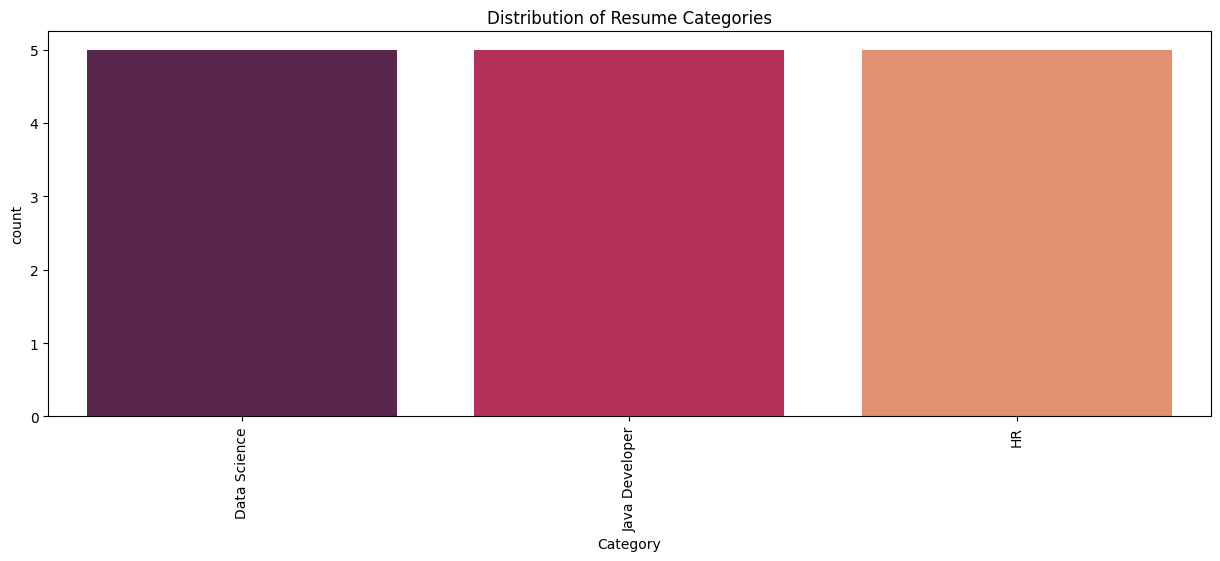

In [9]:
plt.figure(figsize=(15,5))
sns.countplot(data=resume_df, x='Category', palette='rocket')
plt.xticks(rotation=90)
plt.title('Distribution of Resume Categories')
plt.show()

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
from sklearn.preprocessing import LabelEncoder

# 1. Initialize the Encoder
le = LabelEncoder()

# 2. CREATE the missing column 'Category_Encoded'
resume_df['Category_Encoded'] = le.fit_transform(resume_df['Category'])

# 3. Verify it's there
print("Columns now available:", resume_df.columns.tolist())
print(resume_df[['Category', 'Category_Encoded']].head())

Columns now available: ['Category', 'Resume', 'cleaned_resume', 'Category_Encoded']
       Category  Category_Encoded
0  Data Science                 0
1  Data Science                 0
2  Data Science                 0
3  Data Science                 0
4  Data Science                 0


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier

# 1. Vectorize (Turn words into numbers)
word_vectorizer = TfidfVectorizer(sublinear_tf=True, stop_words='english')
X_features = word_vectorizer.fit_transform(resume_df['cleaned_resume'])
y_target = resume_df['Category_Encoded']

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, random_state=42)

# 3. Train the KNN Classifier
clf = OneVsRestClassifier(KNeighborsClassifier())
clf.fit(X_train, y_train)

print(f'Training Accuracy: {clf.score(X_train, y_train):.2f}')
print(f'Test Accuracy: {clf.score(X_test, y_test):.2f}')

Training Accuracy: 0.42
Test Accuracy: 0.00


In [14]:
from sklearn.metrics.pairwise import cosine_similarity

def rank_candidates(job_desc, database_df):
    # 1. Clean the Job Description
    clean_job = clean_resume(job_desc)
    
    # 2. Add the Job Description to the list of resumes
    all_texts = [clean_job] + list(database_df['cleaned_resume'])
    
    # 3. Vectorize everything together
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(all_texts)
    
    # 4. Calculate Similarity between the Job (Index 0) and all Resumes (Index 1+)
    # This measures the "Angle" between the Job and the Resumes
    scores = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:])
    
    # 5. Add scores to the dataframe
    database_df['Match_Score'] = scores[0]
    
    # 6. Return the top matches
    return database_df.sort_values(by='Match_Score', ascending=False)

# --- TEST IT ---
my_job = "Looking for a Data Scientist who knows Python and SQL"
results = rank_candidates(my_job, resume_df)

print("Top 3 Candidates for this Job:")
display(results[['Category', 'Match_Score']].head(3))

Top 3 Candidates for this Job:


,Category,Match_Score
0,Data Science,0.482519
6,Java Developer,0.482519
3,Data Science,0.482519


C:\Users\mymsi\AppData\Local\Temp\ipykernel_2868\2474868271.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Match_Score', y='Category', data=top_candidates, palette='mako')


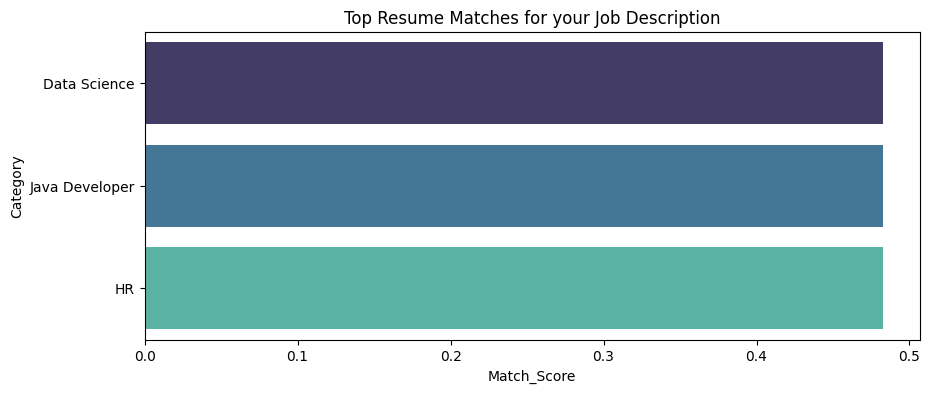

In [15]:
top_candidates = results.head(5)
plt.figure(figsize=(10, 4))
sns.barplot(x='Match_Score', y='Category', data=top_candidates, palette='mako')
plt.title('Top Resume Matches for your Job Description')
plt.show()